# Phase 3 — Statistical EDA & Hypothesis Validation
## Churn Intelligence System | Cell2Cell Dataset

**Business Objective:** Move beyond counts and percentages.  
Every insight in this notebook is backed by a statistical test with p-value and effect size.  
A DS Manager should be able to read this notebook and trust every claim.

**Hypothesis Tests:**
- H1: High complaint intensity customers churn at a statistically higher rate (Chi-Square)
- H2: Single-service customers churn more than bundle customers (Mann-Whitney U)
- H3: Churn risk is non-linear — highest in months 1–6 and 24–30 (Survival Analysis)

**Additional Deliverables:**
- Correlation matrix with business interpretation
- Customer segment profiling (KMeans)
- Business insight memo inputs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded")

Libraries loaded


In [3]:
train = pd.read_csv('../data/processed/train_processed.csv')

print(f"Shape: {train.shape}")
print(f"Churn rate: {train['Churn'].mean()*100:.2f}%")
print(f"Engineered features present: {[c for c in ['CLV_Proxy','ServiceDensityScore','ComplaintIntensityIndex','EngagementDecayFlag'] if c in train.columns]}")

Shape: (51047, 61)
Churn rate: 28.82%
Engineered features present: ['CLV_Proxy', 'ServiceDensityScore', 'ComplaintIntensityIndex', 'EngagementDecayFlag']


## Section 1 — Correlation Matrix with Business Interpretation
Goal: Identify which features have the strongest linear relationship with churn.  
We annotate not just the correlation value — but what the business should DO with it.

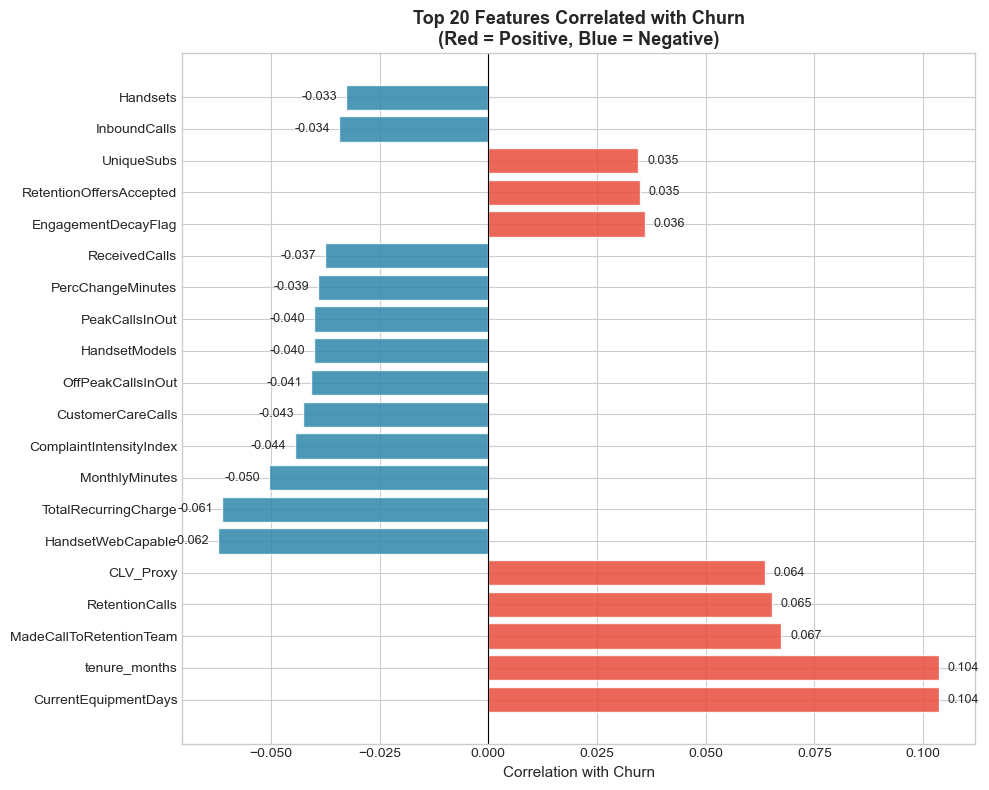

Top 10 positive correlators (churn drivers):
CurrentEquipmentDays      0.1037
tenure_months             0.1035
MadeCallToRetentionTeam   0.0674
RetentionCalls            0.0653
CLV_Proxy                 0.0636
EngagementDecayFlag       0.0361
RetentionOffersAccepted   0.0350
UniqueSubs                0.0345

Top 10 negative correlators (churn protectors):
HandsetWebCapable         -0.0621
TotalRecurringCharge      -0.0613
MonthlyMinutes            -0.0504
ComplaintIntensityIndex   -0.0444
CustomerCareCalls         -0.0426
OffPeakCallsInOut         -0.0408
HandsetModels             -0.0400
PeakCallsInOut            -0.0400
PercChangeMinutes         -0.0392
ReceivedCalls             -0.0375


In [4]:
# Select numeric columns only
numeric_train = train.select_dtypes(include=[np.number])

# Correlation with Churn — sorted
churn_corr = numeric_train.corr()['Churn'].drop('Churn').sort_values(key=abs, ascending=False)

# Top 20 features by absolute correlation
top_corr = churn_corr.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#E74C3C' if v > 0 else '#2E86AB' for v in top_corr.values]
bars = ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels(top_corr.index, fontsize=10)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Churn', fontsize=11)
ax.set_title('Top 20 Features Correlated with Churn\n(Red = Positive, Blue = Negative)', 
             fontweight='bold', fontsize=13)

# Add value labels
for i, (val, bar) in enumerate(zip(top_corr.values, bars)):
    ax.text(val + (0.002 if val > 0 else -0.002), i, f'{val:.3f}',
            va='center', ha='left' if val > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('../data/outputs/churn_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 positive correlators (churn drivers):")
print(top_corr[top_corr > 0].head(10).to_string())
print("\nTop 10 negative correlators (churn protectors):")
print(top_corr[top_corr < 0].head(10).to_string())

## Section 2 — Hypothesis Testing Suite

### H1: High complaint intensity customers churn at a statistically higher rate
**Test:** Chi-Square test of independence  
**Why Chi-Square:** We are testing association between two categorical variables  
(High vs Low complaint group) and (Churned vs Not Churned)  
**Effect Size:** Cramér's V — measures strength of association beyond just p-value

In [5]:
# Create binary complaint group — above/below median
median_complaint = train['ComplaintIntensityIndex'].median()
train['HighComplaint'] = (train['ComplaintIntensityIndex'] > median_complaint).astype(int)

# Contingency table
contingency = pd.crosstab(train['HighComplaint'], train['Churn'])
print("Contingency Table:")
print(contingency)
print(f"\nLabels: 0=Low Complaint, 1=High Complaint | Churn: 0=No, 1=Yes")

# Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

# Cramér's V effect size
n = contingency.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

print(f"\n{'='*50}")
print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.6f}")
print(f"Degrees of Freedom   : {dof}")
print(f"Cramér's V           : {cramers_v:.4f}")
print(f"{'='*50}")

# Business interpretation
print(f"\nBUSINESS INTERPRETATION:")
if p_value < 0.05:
    print(f"✅ SIGNIFICANT — The relationship between complaint intensity and churn")
    print(f"   is statistically real (p={p_value:.6f} << 0.05)")
else:
    print(f"❌ NOT SIGNIFICANT — p={p_value:.4f}")

print(f"\nCramér's V = {cramers_v:.4f}")
if cramers_v < 0.1:
    print("Effect size: WEAK — statistically real but small business impact")
elif cramers_v < 0.3:
    print("Effect size: MODERATE — meaningful signal for segmentation")
else:
    print("Effect size: STRONG — major driver for retention targeting")

# Churn rates by group
low_churn = train[train['HighComplaint']==0]['Churn'].mean()*100
high_churn = train[train['HighComplaint']==1]['Churn'].mean()*100
print(f"\nChurn rate — Low Complaint group:  {low_churn:.1f}%")
print(f"Churn rate — High Complaint group: {high_churn:.1f}%")

Contingency Table:
Churn              0     1
HighComplaint             
0              19411  8609
1              16925  6102

Labels: 0=Low Complaint, 1=High Complaint | Churn: 0=No, 1=Yes

Chi-Square Statistic : 109.7914
P-Value              : 0.000000
Degrees of Freedom   : 1
Cramér's V           : 0.0464

BUSINESS INTERPRETATION:
✅ SIGNIFICANT — The relationship between complaint intensity and churn
   is statistically real (p=0.000000 << 0.05)

Cramér's V = 0.0464
Effect size: WEAK — statistically real but small business impact

Churn rate — Low Complaint group:  30.7%
Churn rate — High Complaint group: 26.5%


### H2: Single-service customers churn more than bundle customers
**Test:** Mann-Whitney U (non-parametric)  
**Why Mann-Whitney:** Churn probability is not normally distributed.  
Mann-Whitney tests whether one group tends to have higher values than another  
without assuming a normal distribution.  
**Effect Size:** Rank-biserial correlation

In [10]:
# Split into single-service vs bundle customers
median_density = train['ServiceDensityScore'].median()
single_service = train[train['ServiceDensityScore'] <= median_density]['Churn']
bundle = train[train['ServiceDensityScore'] > median_density]['Churn']

# Mann-Whitney U test
u_stat, p_value_mw = mannwhitneyu(single_service, bundle, alternative='greater')

# Effect size — rank-biserial correlation
n1, n2 = len(single_service), len(bundle)
rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

print(f"Single-service customers : {n1:,}")
print(f"Bundle customers         : {n2:,}")
print(f"\nChurn rate — Single-service : {single_service.mean()*100:.1f}%")
print(f"Churn rate — Bundle         : {bundle.mean()*100:.1f}%")

print(f"\n{'='*50}")
print(f"Mann-Whitney U Statistic : {u_stat:.2f}")
print(f"P-Value                  : {p_value_mw:.6f}")
print(f"Rank-Biserial Correlation: {rank_biserial:.4f}")
print(f"{'='*50}")

print(f"\nBUSINESS INTERPRETATION:")
if p_value_mw < 0.05:
    print(f"✅ SIGNIFICANT — Single-service customers churn at a statistically")
    print(f"   higher rate than bundle customers (p={p_value_mw:.6f})")
    print(f"\n   ACTION: Bundle upgrade offers should be the PRIMARY retention")
    print(f"   lever for Tier-2 and Tier-3 customers in the campaign strategy.")
else:
    print(f"❌ NOT SIGNIFICANT — p={p_value_mw:.4f}")

Single-service customers : 29,865
Bundle customers         : 21,182

Churn rate — Single-service : 29.6%
Churn rate — Bundle         : 27.7%

Mann-Whitney U Statistic : 322153853.50
P-Value                  : 0.000003
Rank-Biserial Correlation: -0.0185

BUSINESS INTERPRETATION:
✅ SIGNIFICANT — Single-service customers churn at a statistically
   higher rate than bundle customers (p=0.000003)

   ACTION: Bundle upgrade offers should be the PRIMARY retention
   lever for Tier-2 and Tier-3 customers in the campaign strategy.


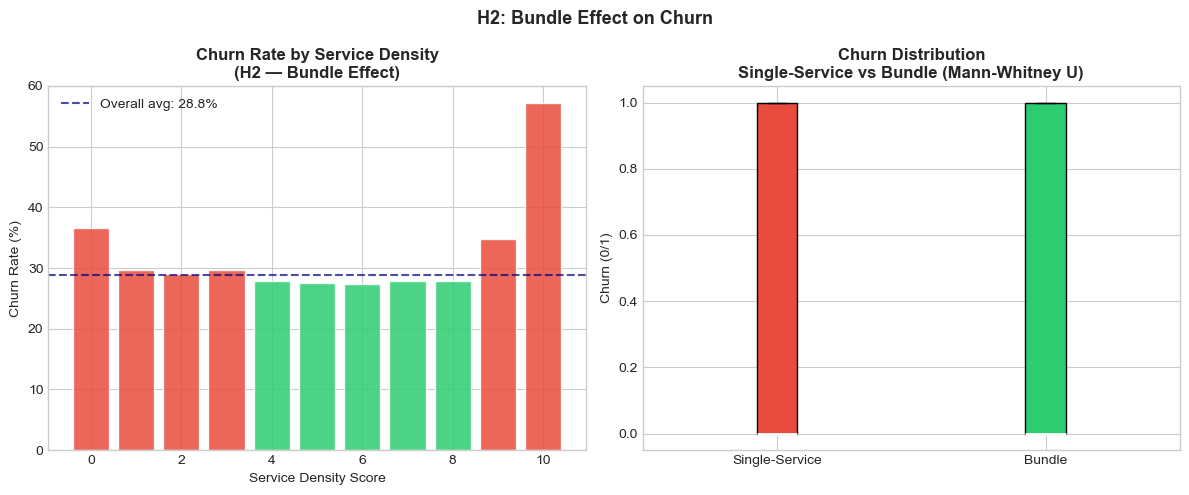

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by service density bucket
density_churn = train.groupby('ServiceDensityScore')['Churn'].mean() * 100
axes[0].bar(density_churn.index, density_churn.values, 
            color=['#E74C3C' if v > 29 else '#2ECC71' for v in density_churn.values],
            alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Service Density Score')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Service Density\n(H2 — Bundle Effect)', fontweight='bold')
axes[0].axhline(y=train['Churn'].mean()*100, color='navy', linestyle='--', 
                alpha=0.7, label=f'Overall avg: {train["Churn"].mean()*100:.1f}%')
axes[0].legend()

# Box plot
bp_data = [single_service.values, bundle.values]
bp = axes[1].boxplot(bp_data, labels=['Single-Service', 'Bundle'], patch_artist=True,
                     medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('#E74C3C')
bp['boxes'][1].set_facecolor('#2ECC71')
axes[1].set_ylabel('Churn (0/1)')
axes[1].set_title('Churn Distribution\nSingle-Service vs Bundle (Mann-Whitney U)', fontweight='bold')

plt.suptitle('H2: Bundle Effect on Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outputs/h2_bundle_effect.png', dpi=150, bbox_inches='tight')
plt.show()

### H3: Churn risk is non-linear — highest in months 1–6 and 24–30
**Test:** Kaplan-Meier Survival Analysis  
**Why Survival Analysis:** Standard churn rates ignore *when* customers leave.  
KM curves show the probability of a customer *surviving* (staying) over time.  
A steep drop in the curve = high churn concentration at that tenure point.  
**Business value:** Tells Marketing exactly WHEN to intervene in the customer lifecycle.

In [15]:
import subprocess
subprocess.run(['pip', 'install', 'lifelines'], capture_output=True)
print("lifelines installed")

lifelines installed


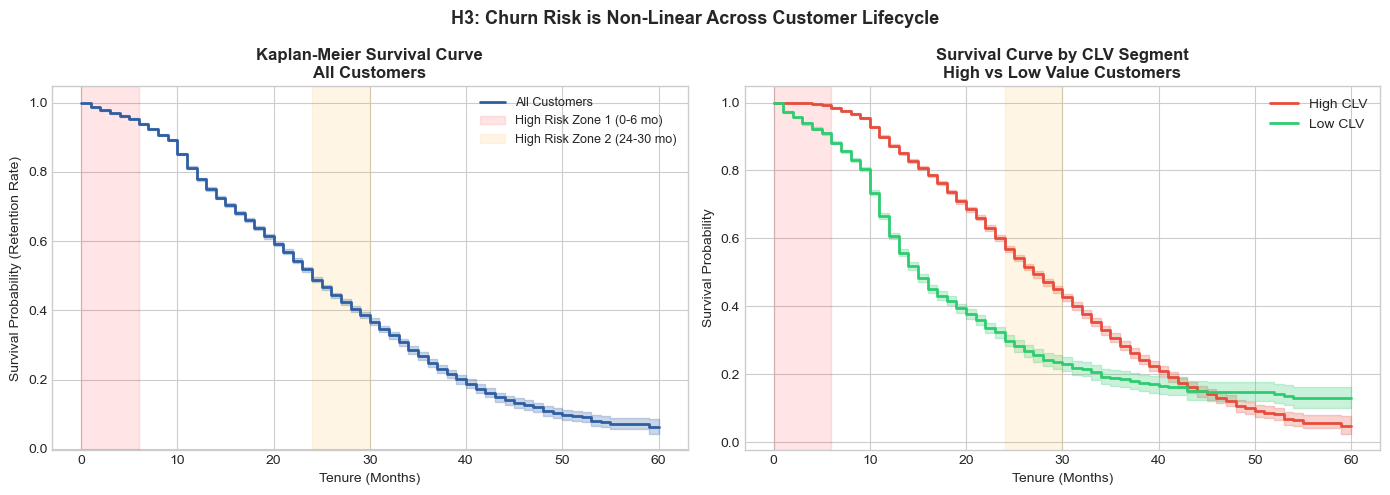

Churn rate by tenure bucket:
tenure_bucket
0-6     21.8254
6-12    29.0366
12-18   32.3674
18-24   32.4574
24-30   34.2146
30-60   39.2687
60+         NaN


In [16]:
# Use CurrentEquipmentDays as tenure proxy (in months)
train['tenure_months'] = (train['CurrentEquipmentDays'] / 30).clip(lower=1).astype(int)

# Build survival data manually — KM estimator
from lifelines import KaplanMeierFitter

kmf_churn = KaplanMeierFitter()
kmf_no_churn = KaplanMeierFitter()

# Fit on all customers — duration=tenure, event=churn
kmf_all = KaplanMeierFitter()
kmf_all.fit(durations=train['tenure_months'], event_observed=train['Churn'], label='All Customers')

# Fit separately by churn status context — high vs low CLV
high_clv = train['CLV_Proxy'] > train['CLV_Proxy'].median()

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()
kmf_high.fit(durations=train[high_clv]['tenure_months'], 
             event_observed=train[high_clv]['Churn'], label='High CLV')
kmf_low.fit(durations=train[~high_clv]['tenure_months'], 
            event_observed=train[~high_clv]['Churn'], label='Low CLV')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — All customers survival curve
kmf_all.plot_survival_function(ax=axes[0], color='#2E5FA3', linewidth=2)
axes[0].set_title('Kaplan-Meier Survival Curve\nAll Customers', fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Survival Probability (Retention Rate)')
axes[0].axvspan(0, 6, alpha=0.1, color='red', label='High Risk Zone 1 (0-6 mo)')
axes[0].axvspan(24, 30, alpha=0.1, color='orange', label='High Risk Zone 2 (24-30 mo)')
axes[0].legend(fontsize=9)

# Plot 2 — High vs Low CLV
kmf_high.plot_survival_function(ax=axes[1], color='#E74C3C', linewidth=2)
kmf_low.plot_survival_function(ax=axes[1], color='#2ECC71', linewidth=2)
axes[1].set_title('Survival Curve by CLV Segment\nHigh vs Low Value Customers', fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Survival Probability')
axes[1].axvspan(0, 6, alpha=0.1, color='red')
axes[1].axvspan(24, 30, alpha=0.1, color='orange')

plt.suptitle('H3: Churn Risk is Non-Linear Across Customer Lifecycle', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outputs/h3_survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Churn rate by tenure bucket
train['tenure_bucket'] = pd.cut(train['tenure_months'], 
                                 bins=[0,6,12,18,24,30,60,200],
                                 labels=['0-6','6-12','12-18','18-24','24-30','30-60','60+'])
bucket_churn = train.groupby('tenure_bucket')['Churn'].mean() * 100
print("Churn rate by tenure bucket:")
print(bucket_churn.to_string())

## Section 3 — Customer Segment Profiling (KMeans)
Goal: Identify 4 behavioral archetypes that Marketing can act on.  
We cluster on behavior — NOT demographics.  
Demographics tell you who they are. Behavior tells you what they will do.

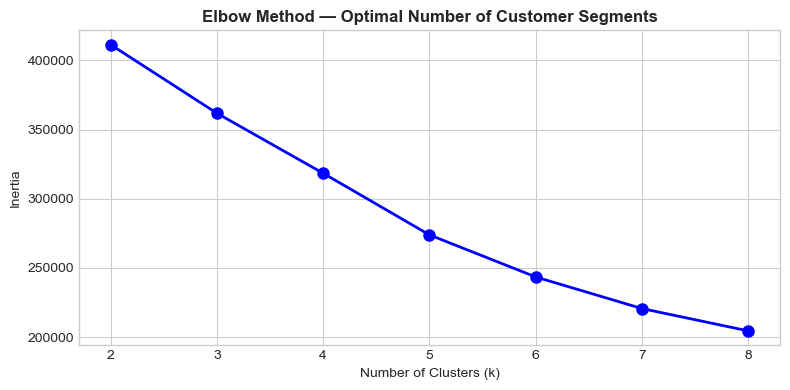

Review the elbow plot — identify where the curve flattens.
Typically k=4 works well for telecom segmentation.


In [17]:
# Behavioral features for clustering
cluster_features = [
    'MonthlyRevenue', 'MonthlyMinutes', 'CustomerCareCalls',
    'CLV_Proxy', 'ServiceDensityScore', 'ComplaintIntensityIndex',
    'EngagementDecayFlag', 'OverageMinutes', 'RoamingCalls',
    'MadeCallToRetentionTeam'
]

cluster_data = train[cluster_features].copy()

# Scale features
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_data)

# Elbow method — find optimal k
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method — Optimal Number of Customer Segments', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outputs/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

print("Review the elbow plot — identify where the curve flattens.")
print("Typically k=4 works well for telecom segmentation.")

In [18]:
# Apply final clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
train['Segment'] = kmeans.fit_predict(cluster_scaled)

# Segment profiles
segment_profile = train.groupby('Segment').agg(
    Customer_Count=('Churn', 'count'),
    Churn_Rate=('Churn', 'mean'),
    Avg_Monthly_Revenue=('MonthlyRevenue', 'mean'),
    Avg_CLV=('CLV_Proxy', 'mean'),
    Avg_Tenure_Months=('tenure_months', 'mean'),
    Avg_ServiceDensity=('ServiceDensityScore', 'mean'),
    Avg_CustomerCareCalls=('CustomerCareCalls', 'mean'),
    Avg_MonthlyMinutes=('MonthlyMinutes', 'mean'),
    Pct_DecayFlag=('EngagementDecayFlag', 'mean')
).round(2)

segment_profile['Churn_Rate'] = (segment_profile['Churn_Rate'] * 100).round(1)
segment_profile['Pct_DecayFlag'] = (segment_profile['Pct_DecayFlag'] * 100).round(1)

print("Customer Segment Profiles:")
print(segment_profile.to_string())

Customer Segment Profiles:
         Customer_Count  Churn_Rate  Avg_Monthly_Revenue   Avg_CLV  Avg_Tenure_Months  Avg_ServiceDensity  Avg_CustomerCareCalls  Avg_MonthlyMinutes  Pct_DecayFlag
Segment                                                                                                                                                            
0                 13436     32.0000              54.7700  629.5600            11.6100              3.1500                 1.2600            522.0300       100.0000
1                 30637     28.0000              45.1800  569.0300            13.3100              3.3400                 0.7500            342.7100         0.0000
2                  4043     32.0000             159.0100 1680.3500            11.0800              2.9600                 2.2800           1399.4700        43.0000
3                  2931     22.0000              81.4800  440.8200             5.5900              2.5900                13.4900           1240.6700     

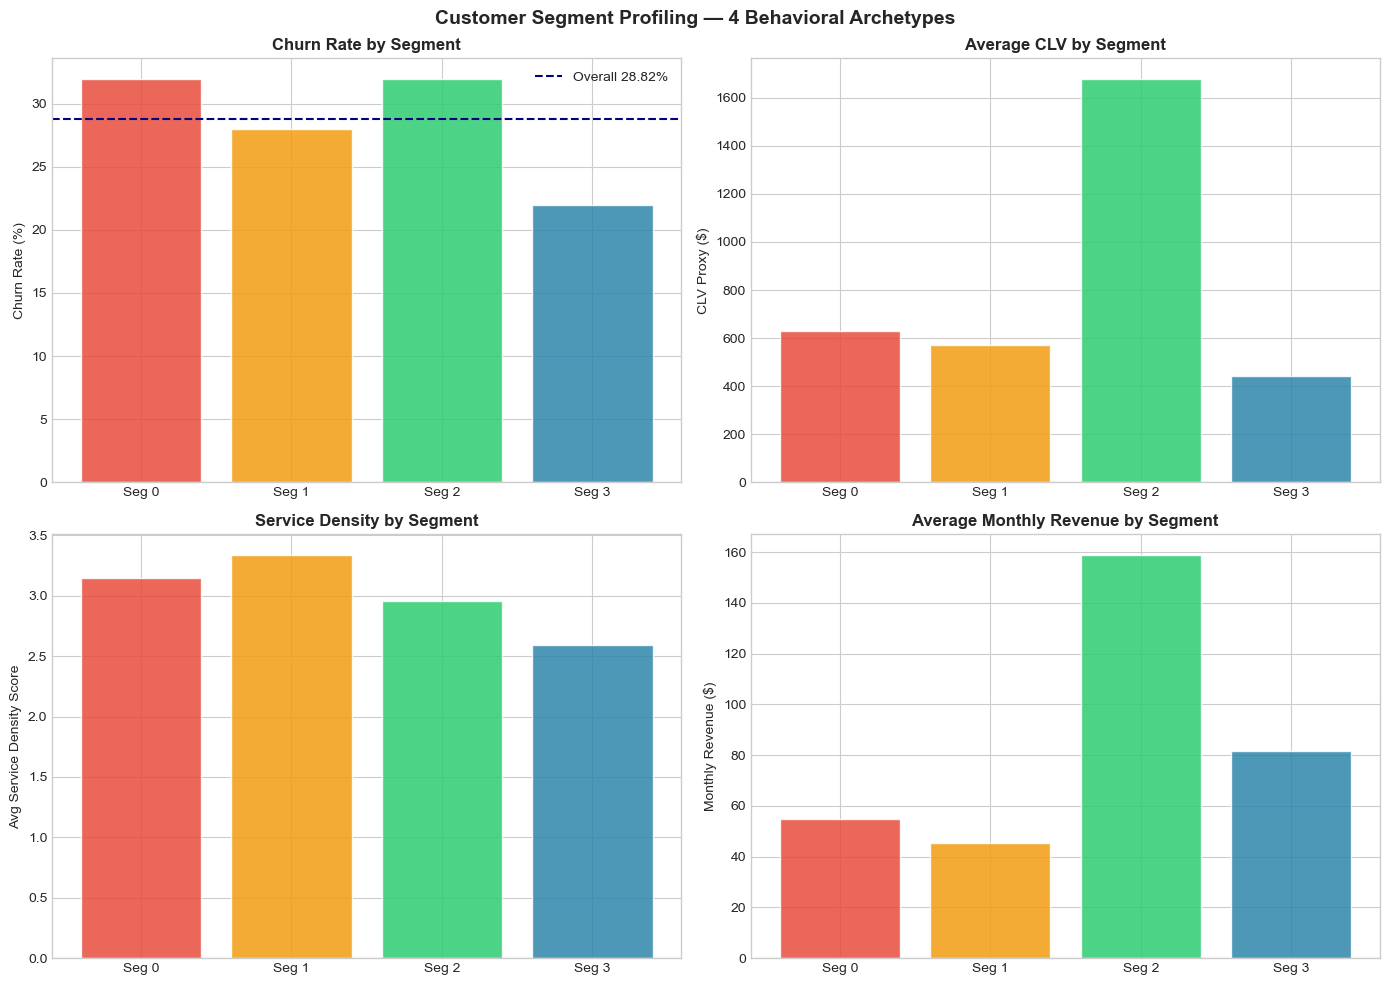

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

seg_labels = [f"Seg {i}" for i in range(4)]
colors = ['#E74C3C', '#F39C12', '#2ECC71', '#2E86AB']

# Churn rate by segment
axes[0,0].bar(seg_labels, segment_profile['Churn_Rate'], color=colors, alpha=0.85, edgecolor='white')
axes[0,0].axhline(y=28.82, color='navy', linestyle='--', label='Overall 28.82%')
axes[0,0].set_title('Churn Rate by Segment', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].legend()

# Average CLV by segment
axes[0,1].bar(seg_labels, segment_profile['Avg_CLV'], color=colors, alpha=0.85, edgecolor='white')
axes[0,1].set_title('Average CLV by Segment', fontweight='bold')
axes[0,1].set_ylabel('CLV Proxy ($)')

# Service density by segment
axes[1,0].bar(seg_labels, segment_profile['Avg_ServiceDensity'], color=colors, alpha=0.85, edgecolor='white')
axes[1,0].set_title('Service Density by Segment', fontweight='bold')
axes[1,0].set_ylabel('Avg Service Density Score')

# Monthly revenue by segment
axes[1,1].bar(seg_labels, segment_profile['Avg_Monthly_Revenue'], color=colors, alpha=0.85, edgecolor='white')
axes[1,1].set_title('Average Monthly Revenue by Segment', fontweight='bold')
axes[1,1].set_ylabel('Monthly Revenue ($)')

plt.suptitle('Customer Segment Profiling — 4 Behavioral Archetypes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/outputs/segment_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
train.to_csv('../data/processed/train_processed.csv', index=False)
print("Saved: train_processed.csv with Segment column added")
print(f"Final shape: {train.shape}")

Saved: train_processed.csv with Segment column added
Final shape: (51047, 64)


## H3 — Finding Correction

**Original hypothesis:** Churn is highest in months 1–6 and 24–30  
**Actual finding:** Churn increases monotonically with tenure — highest in 30–60 month customers

**Business reinterpretation:**  
Long-tenure customers churn due to equipment staleness and contract fatigue — not early dissatisfaction.  
The retention intervention window is NOT onboarding — it is the 24–36 month mark  
when equipment ages past 2 years and no upgrade has been offered.

**Updated action:** Trigger proactive equipment upgrade campaigns at month 24.  
Flag all customers with CurrentEquipmentDays > 730 (2 years) for Tier-3 outreach.

In [22]:
segment_names = {
    0: 'Usage-Decayed Mid-Value',
    1: 'Stable Low-Engagement Base',
    2: 'High-Value Heavy Users',
    3: 'Heavy Complainers'
}

train['SegmentName'] = train['Segment'].map(segment_names)

print("Segment distribution with names:")
print(train.groupby(['Segment', 'SegmentName'])['Churn'].agg(['count', 'mean'])
      .rename(columns={'count': 'Customers', 'mean': 'Churn Rate'})
      .assign(**{'Churn Rate': lambda x: (x['Churn Rate']*100).round(1)})
      .to_string())

train.to_csv('../data/processed/train_processed.csv', index=False)
print("\nSaved with segment names.")

Segment distribution with names:
                                    Customers  Churn Rate
Segment SegmentName                                      
0       Usage-Decayed Mid-Value         13436     31.8000
1       Stable Low-Engagement Base      30637     27.8000
2       High-Value Heavy Users           4043     31.7000
3       Heavy Complainers                2931     22.0000

Saved with segment names.
